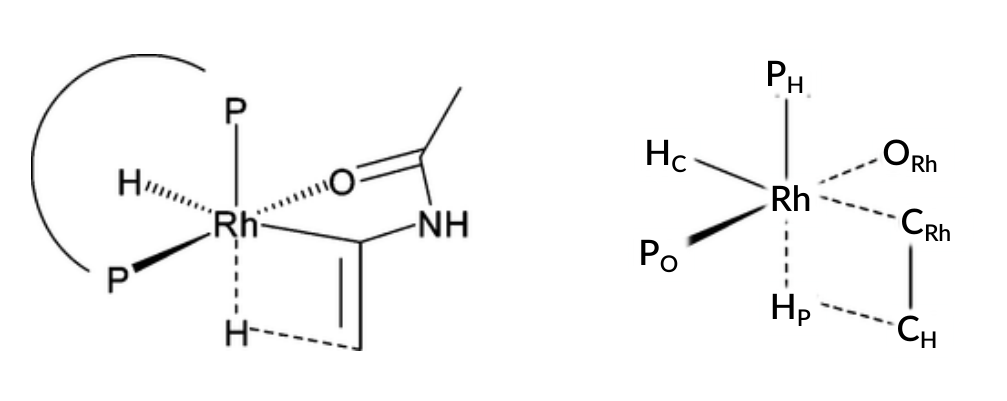

In [1]:
from IPython.display import Image
Image(filename='/home/mfarrugi/Documents/Rh_figures/rh_system_defn.png')

**Rhodium Hydrogenation of Enamides TSFF Parameterized by a new Hybrid Optimizer**

Rh Hyd Enamides TSFF as a test case for the use of a new Hybrid Particle Swarm-Differential Evolution Optimization Algorithm (hybrid_optimizer) developed by Mikaela Farrugia (github: @mmfarrugia) under Olaf Wiest & Paul Helquist.

These are all being run with the pbest localization as convergence criterion.
Note: Score distributions are incorrect due to funky mm3.fld vs mm3.hybrid.fld issue which is now fixed but untested/unrun

### Global Settings Configuration & Imports

In [3]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import sys
from matplotlib import animation, rc
from IPython.display import HTML, Image
import seaborn
import pickle
import pandas as pd
from numpy import copy
from scipy import stats
import itertools

seaborn.set_theme(style="whitegrid")

zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080', '#528D6A']
zesty2 = ['#F65300', '#6e3a69', '#6793bc', '#081142', '#39634a'] #c86431
zesty_palette = seaborn.color_palette(palette=zesty)
zesty2_palette = seaborn.color_palette(palette=zesty2)
edges = itertools.cycle(zesty2_palette)
palette = itertools.cycle(zesty_palette)
palette = itertools.cycle(zesty_palette)
edges = itertools.cycle(zesty2_palette)

#src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm/q2mm")
sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.8/site-packages/q2mm-0.0.0-py3.8.egg")

#from hybrid_optimizer import PSO_GA
import q2mm.hybrid_optimizer as hybrid_optimizer
from q2mm.hybrid_optimizer import PSO_DE
import tools.ff_plotting as ffplt



In [4]:
bond_cols = ["param_type", "atom1", "atom2", "Equilibrium Value", "Force Constant", "Dipole Moment", "FF"]
angle_cols = ["param_type", "atom1", "atom2", "atom3", "Equilibrium Value", "Force Constant", "FF"]
score_cols = ["Label", "Weight", "Reference", "Calculated", "Score", "FF"]
skiprows=[0, 1, 106390, 106391, 106392, 106393, 106394, 106395, 106396, 106397, 106398, 106399, 106400, 106401]
bond_rows = np.arange(1859, 1867)
angle_rows = np.concatenate((np.arange(1867, 1889), [1908]))
bonds_rows = [str(bond_row+1) for bond_row in bond_rows]
angles_rows = [str(angle_row+1) for angle_row in angle_rows]
ff_rows = np.concatenate((bond_rows, angle_rows))
ffs_rows = [str(ff_row + 1) for ff_row in ff_rows]

print ('FF Rows: ')
print(ff_rows)
convergence_criteria = 0.001
num_params = 31
substructure_strings = ['HX-RH(-PX)-HX.C2*C2(.2)-N2-C2=O2.2', 'RH-PX']
param_names = ['Hc-Rh', 'Rh-P\u2095', 'Rh-P\u2092', 'Rh-H\u209A', 'Rh.CRh', 'Rh.ORh', 'H\u209A.C\u2095', 'C\u2095*CRh', 'Hc-Rh-P\u2095', 'Hc-Rh-P\u2092', 'Hc-Rh-H\u209A', 'Hc-Rh.CRh', 'Hc-Rh.ORh', 'P\u2095-Rh-H\u209A', 'P\u2092-Rh-H\u209A', 'P\u2095-Rh.CRh', 'P\u2092-Rh.CRh', 'P\u2095-Rh.ORh','P\u2092-Rh.ORh', 'H\u209A-Rh.CRh', 'H\u209A-Rh.ORh', 'CRh.Rh.ORh', 'Rh-H\u209A.C\u2095', 'H\u209A.C\u2095*00', 'CRh*C\u2095.H\u209A', 'Rh.CRh*C0', 'Rh.CRh*C2o', 'Rh.CRh*C\u2095', 'Rh.CRh-N2', 'Rh.ORh=C2', 'P\u209A-Rh-P\u2095']
print(param_names)

FF Rows: 
[1859 1860 1861 1862 1863 1864 1865 1866 1867 1868 1869 1870 1871 1872
 1873 1874 1875 1876 1877 1878 1879 1880 1881 1882 1883 1884 1885 1886
 1887 1888 1908]
['Hc-Rh', 'Rh-Pₕ', 'Rh-Pₒ', 'Rh-Hₚ', 'Rh.CRh', 'Rh.ORh', 'Hₚ.Cₕ', 'Cₕ*CRh', 'Hc-Rh-Pₕ', 'Hc-Rh-Pₒ', 'Hc-Rh-Hₚ', 'Hc-Rh.CRh', 'Hc-Rh.ORh', 'Pₕ-Rh-Hₚ', 'Pₒ-Rh-Hₚ', 'Pₕ-Rh.CRh', 'Pₒ-Rh.CRh', 'Pₕ-Rh.ORh', 'Pₒ-Rh.ORh', 'Hₚ-Rh.CRh', 'Hₚ-Rh.ORh', 'CRh.Rh.ORh', 'Rh-Hₚ.Cₕ', 'Hₚ.Cₕ*00', 'CRh*Cₕ.Hₚ', 'Rh.CRh*C0', 'Rh.CRh*C2o', 'Rh.CRh*Cₕ', 'Rh.CRh-N2', 'Rh.ORh=C2', 'Pₚ-Rh-Pₕ']


### METHODS


Further information regarding the settings, files, and parameters used in the optimizations can be found in their respective directories under the README.txt file.

All hyperparameters are derived from literature **INCLUDE REFS** and use the TIGHT_OPT_CONFIG.

It was found that, as expected based on Lime & Norrby 20**, optimization should first be done without artificially increasing the rxn coordinate FC ('natural' TS) before optimizing again at the end and passing a ff row # as the last argument of the HYBR input line in the loop.in file to forcefully inflate the value of the rxn coordinate FC (1865 in this case)

### Start: FUERZA estimated FCs + Donoghue charges

Original Score: 1.36078

In [5]:
# Gather data on starting point

fuerza_score = 1.36077746

qf_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/rh_qf_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=fuerza_score)

bond_start = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/mm3.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_score)
angle_start = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/mm3.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_score)

bond_start = bond_start.assign(ff_row=bonds_rows).assign(atom3='-')
angle_start = angle_start.assign(ff_row=angles_rows)
params_start = pd.concat([bond_start, angle_start])
melted_params_start = pd.melt(params_start, id_vars=['param_type', 'atom1', 'atom2', 'atom3', 'ff_row'], value_vars=['Force Constant'])
params_start


/tmp/ipykernel_290761/2669767809.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  qf_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/rh_qf_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=fuerza_score)
/tmp/ipykernel_290761/2669767809.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  bond_start = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/mm3.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_score)
/tmp/ipykernel_290761/2669767809.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  angle_start = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/q_fuerza/mm3.fld', skiprows=lamb

,param_type,atom1,atom2,Equilibrium Value,Force Constant,Dipole Moment,FF,ff_row,atom3
0,1,1,2,1.5626,2.2724,-0.4611,1.360777,1860,-
1,1,2,3,2.3924,0.8141,-6.6928,1.360777,1861,-
2,a1,2,3,2.2916,1.3697,-5.0068,1.360777,1862,-
3,1,2,4,1.6253,1.1033,-1.5657,1.360777,1863,-
4,1,2,6,2.3388,0.1620,1.8318,1.360777,1864,-
5,1,2,9,2.2247,0.5331,0.6528,1.360777,1865,-
6,1,4,5,1.7099,3.8474,-1.3716,1.360777,1866,-
7,1,5,6,1.4222,4.4167,-1.5340,1.360777,1867,-
0,2,1,2,84.1864,0.9640,NaN,1.360777,1868,3
1,a2,1,2,79.2428,1.3711,NaN,1.360777,1869,3


### Donoghue: Donoghue FCs + Donoghue charges

Original Score: 3.4894

In [6]:
# Gather data on starting point

donoghue_score = 3.4894

donoghue_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/rh_donoghue_final_scores.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_score)

bond_don = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/ff/rh_hyd_enamide_final.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=donoghue_score)
angle_don = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/ff/rh_hyd_enamide_final.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=donoghue_score)

bond_don = bond_start.assign(ff_row=bonds_rows).assign(atom3='-')
angle_don = angle_start.assign(ff_row=angles_rows)
params_don = pd.concat([bond_don, angle_don])
melted_params_don = pd.melt(params_don, id_vars=['param_type', 'atom1', 'atom2', 'atom3', 'ff_row'], value_vars=['Force Constant'])
params_don


/tmp/ipykernel_290761/2796339916.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  donoghue_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/rh_donoghue_final_scores.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_score)
/tmp/ipykernel_290761/2796339916.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  bond_don = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/ff/rh_hyd_enamide_final.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=donoghue_score)
/tmp/ipykernel_290761/2796339916.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  angle_don = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/ff/rh_hyd_enamide_fin

,param_type,atom1,atom2,Equilibrium Value,Force Constant,Dipole Moment,FF,ff_row,atom3
0,1,1,2,1.5626,2.2724,-0.4611,1.360777,1860,-
1,1,2,3,2.3924,0.8141,-6.6928,1.360777,1861,-
2,a1,2,3,2.2916,1.3697,-5.0068,1.360777,1862,-
3,1,2,4,1.6253,1.1033,-1.5657,1.360777,1863,-
4,1,2,6,2.3388,0.1620,1.8318,1.360777,1864,-
5,1,2,9,2.2247,0.5331,0.6528,1.360777,1865,-
6,1,4,5,1.7099,3.8474,-1.3716,1.360777,1866,-
7,1,5,6,1.4222,4.4167,-1.5340,1.360777,1867,-
0,2,1,2,84.1864,0.9640,NaN,1.360777,1868,3
1,a2,1,2,79.2428,1.3711,NaN,1.360777,1869,3


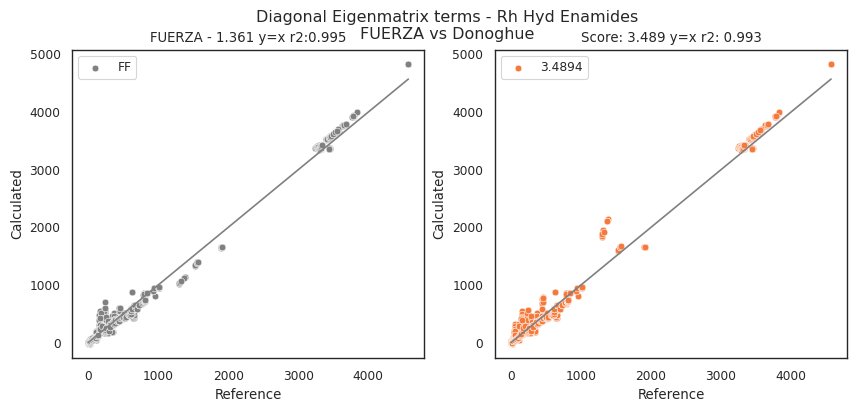

In [7]:
ffplt.linear_fit_diag_scores(qf_scores, fuerza_score, [donoghue_scores], [donoghue_score], ' - Rh Hyd Enamides\nFUERZA vs Donoghue')

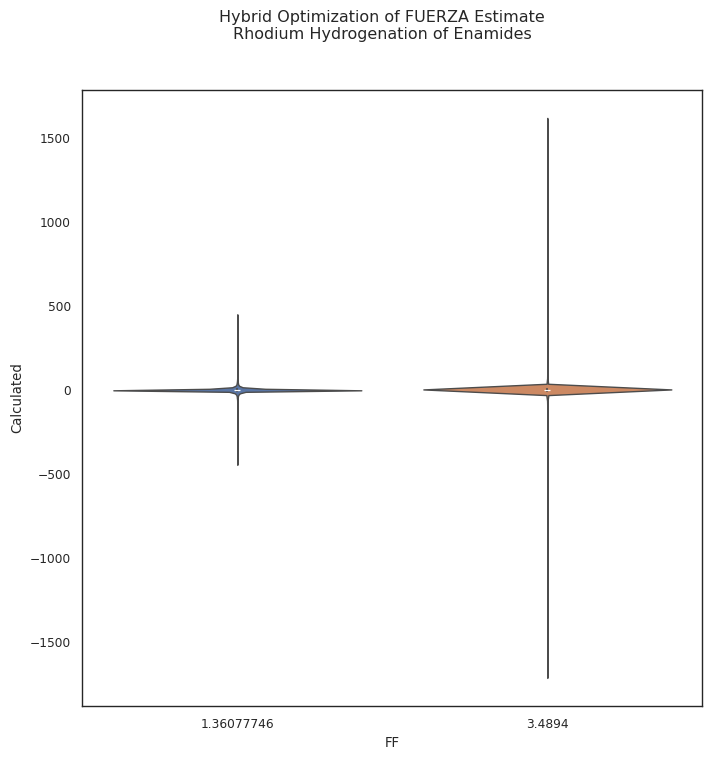

In [8]:
ffplt.plot_off_diag_violin(qf_scores, fuerza_score, [donoghue_scores],[donoghue_score], 'Hybrid Optimization of FUERZA Estimate\nRhodium Hydrogenation of Enamides')

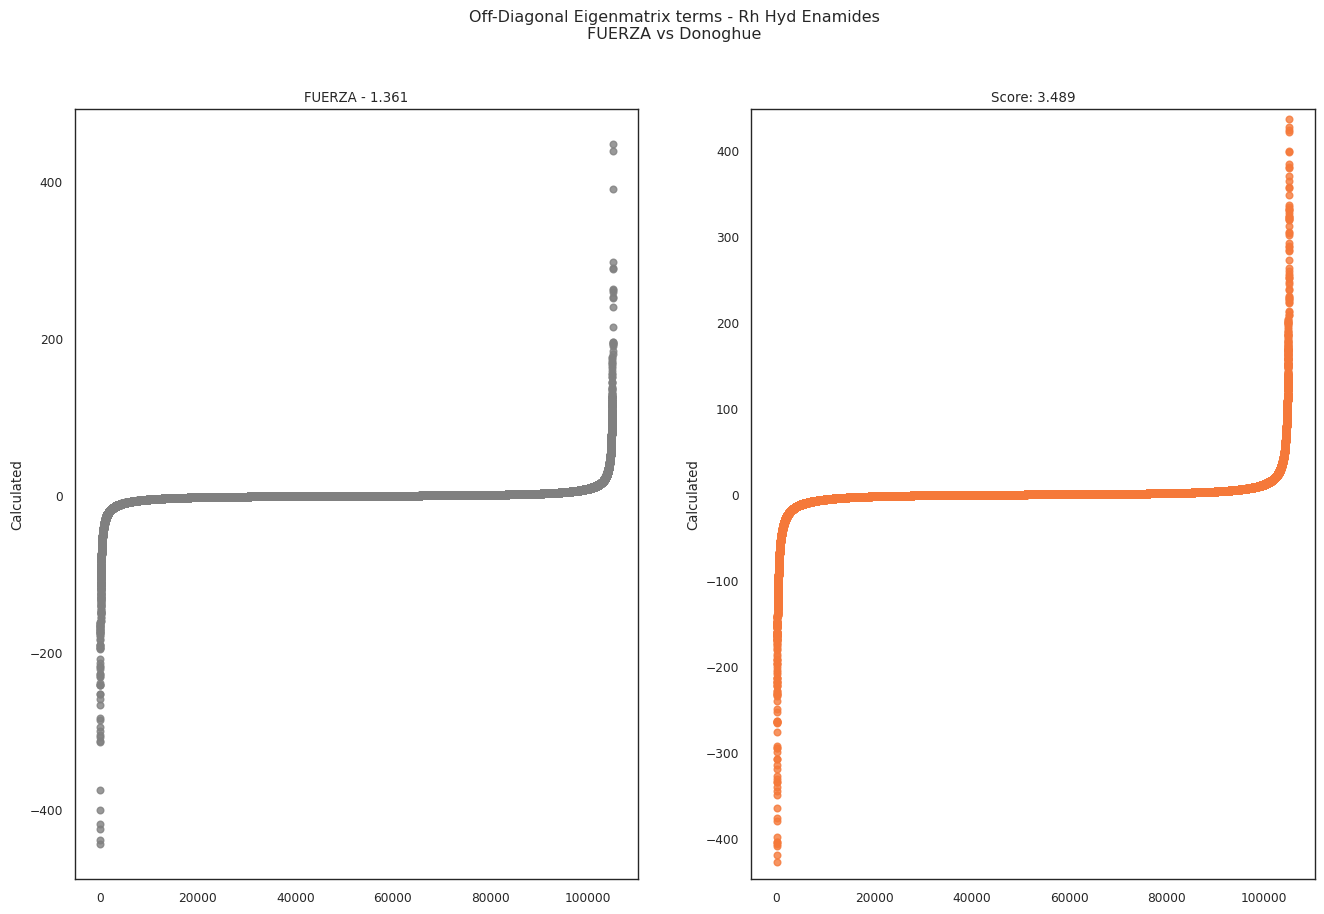

In [9]:
ffplt.plot_off_diag_scatter(qf_scores, fuerza_score, [donoghue_scores], [donoghue_score], ' - Rh Hyd Enamides\nFUERZA vs Donoghue')

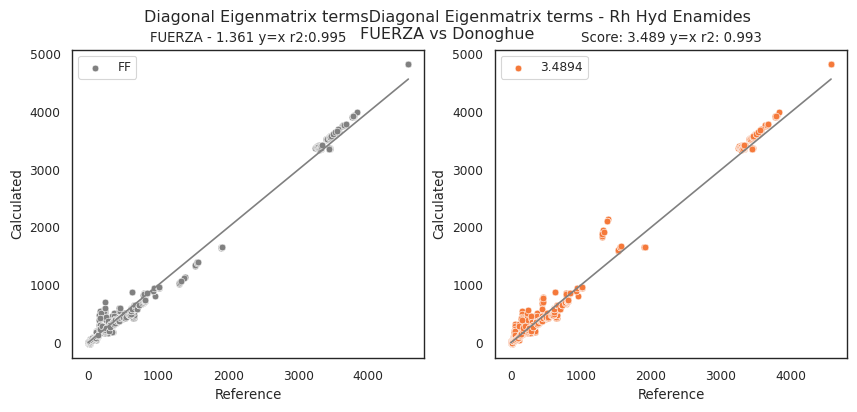

In [10]:
ffplt.linear_fit_diag_scores(qf_scores, fuerza_score, [donoghue_scores], [donoghue_score], 'Diagonal Eigenmatrix terms - Rh Hyd Enamides\nFUERZA vs Donoghue')

In [11]:
cumulative_params = []

### 20 FF 200 iter

In [12]:
base_directory = '/home/mfarrugi/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter'
num_particles = 20
cycle_iter_length = 200
directory_list = ['', '9', '1_crc_io_err', 'crc_call_failed_cycle_3', '2_crc_nonetype_err']

FileNotFoundError: [Errno 2] No such file or directory: '/home/mfarrugi/repos/q2mm/rh-hybrid/conv_crit/local_best_x/7/hybrid_opt_history.bin'

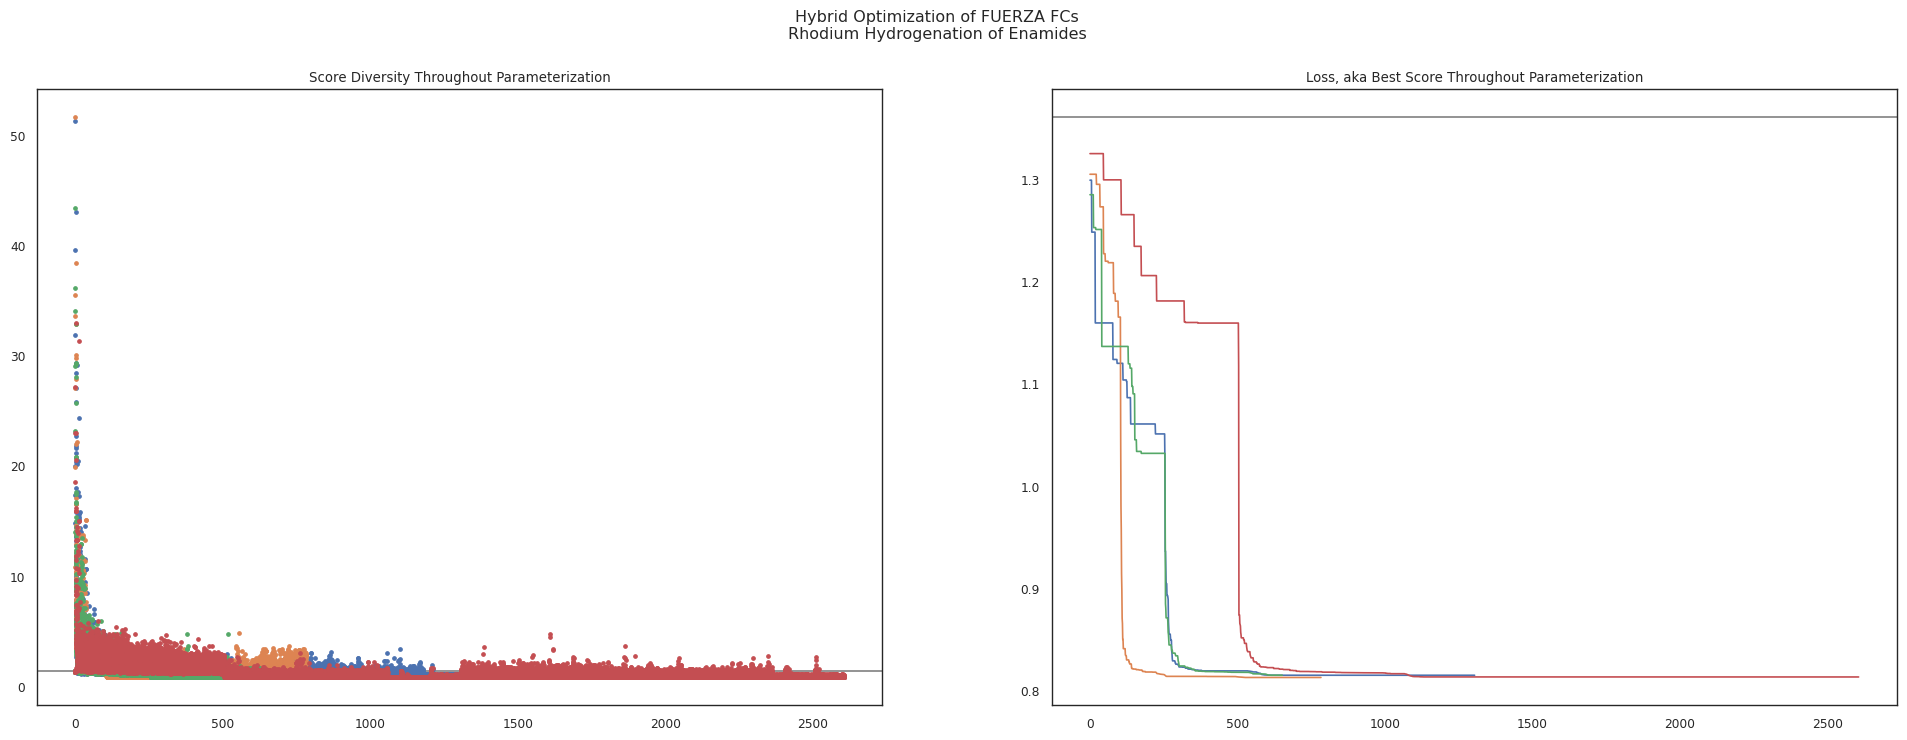

In [16]:
scores = ffplt.plot_history(base_directory, directory_list[:-1], 'Hybrid Optimization of FUERZA FCs\nRhodium Hydrogenation of Enamides', cycle_iter_length, fuerza_score)

In [ ]:
# Plot Scores
directory_list = ['', '1_crc_io_err', '2_crc_nonetype_err', 'crc_call_failed_cycle_3']
scores[-1] = 0.8173
runs = []
for directory, score in zip(directory_list[:-1], scores):
    runs.append(pd.read_csv(os.path.join(base_directory, directory, 'rh_qf_ho_end.txt'), skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=score))


In [ ]:
ffplt.linear_fit_diag_scores(qf_scores, fuerza_score, runs, scores, 'Diagonal Eigenmatrix terms after a tapered HO - Rh Hyd Enamides')

#### Score Analysis

In [ ]:
ffplt.plot_off_diag_scatter(qf_scores, fuerza_score, runs, scores,'Hybrid Optimization of FUERZA Estimate\nRhodium Hydrogenation of Enamides')

In [ ]:
ffplt.plot_off_diag_violin(qf_scores, fuerza_score, runs, scores, 'Hybrid Optimization of FUERZA Estimate\nRhodium Hydrogenation of Enamides')

In [ ]:
ffplt.plot_scores(qf_scores, fuerza_score, runs, scores, 'Hybrid Optimization of FUERZA Estimate\nRhodium Hydrogenation of Enamides')

#### FC Analysis

In [15]:
%matplotlib inline
# Plot FCs

bonds = []
angles = []

bonds_rows = [str(bond_row+1) for bond_row in bond_rows]
angles_rows = [str(angle_row+1) for angle_row in angle_rows]

for directory, score in zip(directory_list[:-1], scores):
    bonds.append(pd.read_csv(os.path.join(base_directory, directory, 'mm3.hybrid.fld'), skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=score).assign(ff_row = bonds_rows))
    angles.append(pd.read_csv(os.path.join(base_directory, directory, 'mm3.hybrid.fld'), skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=score).assign(ff_row=angles_rows))
params = [pd.concat([bond, angle]) for bond, angle in zip(bonds, angles)]
cumulative_params.extend(params)

NameError: name 'scores' is not defined

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a tapered HO - Rh Hyd Enamides')
ax[0].set_title('Bonds')
ax[1].set_title('Angles')

palette = itertools.cycle(seaborn.color_palette())

color = next(palette)
seaborn.regplot(data=bond_start, label='FUERZA', x = bond_start.index, y="Force Constant", fit_reg=False, ax=ax[0], marker='X', scatter_kws={'s':150}, color=color)
seaborn.regplot(data=angle_start, label='FUERZA', x = angle_start.index, y="Force Constant", fit_reg=False, ax=ax[1], marker='X', scatter_kws={'s':150}, color=color)
print(len(bonds))
bond_labels = bonds[0][['atom1', 'atom2', 'param_type']].values
bond_labels = [str(bl) for bl in bond_labels]
angles_labels = angles[0][['atom1', 'atom2', 'atom3', 'param_type']].values
angles_labels = [str(al) for al in angles_labels]
print(bond_labels)
for i in range(len(directory_list[:-1])):
    color = next(palette)
    seaborn.regplot(data=bonds[i], label=scores[i], x = bond_labels, y="Force Constant", fit_reg=False, ax=ax[0], color=color)
    seaborn.regplot(data=angles[i], label=scores[i], x = angles_labels, y="Force Constant", fit_reg=False, ax=ax[1], color=color)

plt.xticks(rotation=45)
ax[1].legend()
ax[0].set_ylabel('Force Constant (mdyne/Ang)')
ax[1].set_ylabel('Force Constant (mdyne/Ang)')
ax[0].set_xlabel('atom1, atom2, param_type')
ax[1].set_xlabel('atom1, atom2, atom3, param_type')
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a tapered HO - Rh Hyd Enamides')

palette = itertools.cycle(seaborn.color_palette())

color = next(palette)
seaborn.regplot(data=melted_params_start, label='FUERZA', x = melted_params_start.ff_row, y="value", fit_reg=False, ax=ax, color=color)
seaborn.regplot(data=params_start, label='FUERZA', x =params_start.ff_row, y="Force Constant", marker='X', scatter_kws={'s':150}, fit_reg=False, ax=ax, color=color)

bond_labels = bonds[0][['atom1', 'atom2', 'param_type']].values
bond_labels = [str(bl) for bl in bond_labels]
angles_labels = angles[0][['atom1', 'atom2', 'atom3', 'param_type']].values
angles_labels = [str(al) for al in angles_labels]

for i in range(len(directory_list[:-1])):
    color = next(palette)
    seaborn.regplot(data=params[i], label=scores[i], x = params[i].ff_row, y="Force Constant", fit_reg=False, ax=ax, color=color)
    #seaborn.regplot(data=bonds[i], label=scores[i], x = rows[:8], y="Force Constant", fit_reg=False, ax=ax, color=color)
    #seaborn.regplot(data=angles[i], label=scores[i], x = rows[9:], y="Force Constant", fit_reg=False, ax=ax, color=color)

rows = [*bond_rows, *angle_rows]
rows = [str(row+1) for row in rows]

plt.xticks(rotation=45)
ax.legend()
ax.set_ylabel('Force Constant (mdyne/Ang)')
ax.set_xlabel('atom1, atom2, param_type')
plt.xticks(ticks=rows, labels=param_names)
plt.show()

In [ ]:
#plot final x
%matplotlib inline

def plot_last_x(history:dict, rows:list, title:str=''):
    fig, ax = plt.subplots(1, 1, figsize=(24, 8))
    fig.suptitle('Force Constants'+title)

    X_history = history["X"]
    last_X = X_history[-1]
    palette = itertools.cycle(seaborn.color_palette())

    for i, particle in enumerate(last_X):
        color = next(palette)
        seaborn.regplot(x=rows, y=particle, fit_reg=False, label=i, ax=ax, color=color)

    ax.legend()
    ax.set_ylabel('Force Constant (mdyne/Ang)')
    plt.show()

fig, ax = plt.subplots(1, 2, figsize=(24, 8))
swarm_history_file = open(os.path.join(base_directory, directory_list[0], 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])
color = next(ax[0]._get_lines.prop_cycler)['color']

rows = [*bond_rows, *angle_rows]
rows = [str(row+1) for row in rows]
print(len(rows))
print(rows)

plot_last_x(swarm_history, rows)
plt.xticks(ticks=rows, labels=param_names)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(24, 8))
swarm_history_file = open(os.path.join(base_directory, directory_list[1], 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])
color = next(ax[0]._get_lines.prop_cycler)['color']

rows = [*bond_rows, *angle_rows]
rows = [str(row+1) for row in rows]
print(len(rows))
print(rows)

plot_last_x(swarm_history, rows)
plt.xticks(ticks=rows, labels=param_names)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a tapered HO - Rh Hyd Enamides')

palette = itertools.cycle(seaborn.color_palette())

color = next(palette)
seaborn.regplot(data=melted_params_start, label='FUERZA', x = melted_params_start.ff_row, y="value", fit_reg=False, ax=ax, color=color)
#seaborn.regplot(data=bond_start, label='FUERZA', x = bond_start.index, y="Force Constant", fit_reg=False, ax=ax, color=color)
#
bond_labels = bonds[0][['atom1', 'atom2', 'param_type']].values
bond_labels = [str(bl) for bl in bond_labels]
angles_labels = angles[0][['atom1', 'atom2', 'atom3', 'param_type']].values
angles_labels = [str(al) for al in angles_labels]
print(bond_labels)
rows = [*bond_rows, *angle_rows]
rows = [str(row+1) for row in rows]
print(rows)
print(len(rows))
color = next(palette)
for i in range(len(directory_list[:-1])):
    seaborn.regplot(data=params[i], label=scores[i], x = params[i].ff_row, y="Force Constant", fit_reg=False, ax=ax, color=color)
    # seaborn.regplot(data=bonds[i], label=np.round(scores[i], 4), x = rows[:8], y="Force Constant", fit_reg=False, ax=ax, color=color)
    # seaborn.regplot(data=angles[i], label=np.round(scores[i], 4), x = rows[9:], y="Force Constant", fit_reg=False, ax=ax, color=color)

plt.xticks(rotation=45)


#plot final x

def plot_last_x(history:dict, rows:list, title:str=''):

    X_history = history["X"]
    last_X = X_history[-1]

    for i, particle in enumerate(last_X):
        seaborn.regplot(x=rows, y=particle, fit_reg=False, label=i if i == 0 else None, ax=ax, color=color)

swarm_history_file = open(os.path.join(base_directory, directory_list[0], 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])
color = next(palette)

plot_last_x(swarm_history, rows)

swarm_history_file = open(os.path.join(base_directory, directory_list[1], 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])
color = next(palette)

plot_last_x(swarm_history, rows)

ax.legend()
ax.set_ylabel('Force Constant (mdyne/Ang)')
plt.xticks(ticks=rows, labels=param_names)
plt.show()

### Univariate Analysis of 20 FF 200 iter data

In [ ]:
swarm_history_file = open(os.path.join(base_directory, directory_list[0], 'hybrid_opt_history.bin'), 'rb')
swarm_history = pickle.load(swarm_history_file)
swarm_history_file.close()
num_iters = len(swarm_history['Y'])
num_ffs = len(swarm_history['Y'][0])

X_history = np.array(swarm_history['X']).reshape((num_iters*num_ffs, num_params))
Y_history = np.array(swarm_history['Y']).reshape((num_iters*num_ffs, 1))

history = pd.DataFrame(X_history, columns=param_names).assign(score=Y_history)
#param_history = X_history[:,:,param_index]
history = history[history['score'] <= 1.5]
history

In [ ]:
seaborn.pairplot(history.sample(200), hue='score', palette='mako', diag_kind='hist')
plt.legend()

In [ ]:
seaborn.pairplot(history.tail(200), hue='score', palette='mako', diag_kind='hist')
plt.legend()

Takeaways:

Tight

PH-Rh.ORh with PO-Rh-PH;
CRh*CH.HP

Ineffective

CRh.Rh.ORh;
PO-PH.CRh;
PO/H-Rh.CRh;
Rh-PO/H;


In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
import umap

reducer = umap.UMAP()

history_data = history.values
scaled_history_data = StandardScaler().fit_transform(history_data)
scaled_history = pd.DataFrame(scaled_history_data, columns=param_names+['score']).rename(columns={31:'score'})
scaled_history

In [ ]:
seaborn.pairplot(scaled_history.sample(200), hue='score', palette='mako', diag_kind='hist')
plt.legend()

In [ ]:
history['scaled_score'] = scaled_history.score.values
seaborn.pairplot(history.tail(200), hue='scaled_score', palette='mako', diag_kind='hist')
plt.legend()

In [ ]:
# Harder history filter on scores
tight_history = history[history['score'] <= 0.82]
tight_history_data = tight_history.values
tight_scaled_history_data = StandardScaler().fit_transform(tight_history_data)
tight_scaled_history = pd.DataFrame(tight_scaled_history_data, columns=param_names+['score']).rename(columns={31:'score'})
tight_scaled_history

In [ ]:
seaborn.pairplot(tight_scaled_history.sample(200), hue='score', palette='mako', diag_kind='hist')
plt.legend()

In [ ]:
# plot only last 50 iters
seaborn.pairplot(tight_scaled_history.tail(200), hue='score', palette='mako', diag_kind='hist')
plt.legend()

### UMAP of 20 FF 200 iter Data

In [26]:
embedding = reducer.fit_transform(scaled_history_data)
embedding.shape

NameError: name 'reducer' is not defined

In [27]:
embedded = pd.DataFrame(embedding).assign(score = scaled_history.score.values)
subset = embedded.sample(1000)
embedded

NameError: name 'embedding' is not defined

In [28]:
#seaborn.scatterplot(subset, hue=subset.score, palette='mako')
seaborn.scatterplot(data=subset, x=0, y=1, hue=subset.score, palette='mako')
plt.gca().set_aspect('equal', 'datalim')
plt.legend()

NameError: name 'subset' is not defined

Redo above UMAP embedding but without the score included in the data for the embedding

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
import umap

reducer = umap.UMAP()

history_data = history.drop('score', axis=1).values
scaled_history_data = StandardScaler().fit_transform(history_data)



In [ ]:
embedding = reducer.fit_transform(scaled_history_data)
embedding.shape

In [ ]:
embedded = pd.DataFrame(embedding).assign(score = scaled_history.score.values)
subset = embedded.sample(1000)
embedded

In [ ]:
#seaborn.scatterplot(subset, hue=subset.score, palette='mako')
seaborn.scatterplot(data=embedded, x=0, y=1, hue=subset.score, palette='mako')
plt.gca().set_aspect('equal', 'datalim')
plt.legend()

In [ ]:
#Redo with tight scores

reducer = umap.UMAP()

In [ ]:
embedding = reducer.fit_transform(tight_scaled_history_data)
embedding.shape

In [ ]:
embedded = pd.DataFrame(embedding).assign(score = tight_scaled_history.score.values)
subset = embedded.sample(1000)
embedded

In [ ]:
#seaborn.scatterplot(subset, hue=subset.score, palette='mako')
seaborn.scatterplot(data=embedded, x=0, y=1, hue=subset.score, palette='mako')
plt.gca().set_aspect('equal', 'datalim')
plt.legend()

Try removing the parameters (features) which don't have much effect

In [ ]:
print(param_names[15], param_names[16], param_names[21])
reducer = umap.UMAP()

dropped_history_data = tight_history.drop(labels=['score', param_names[15], param_names[16], param_names[21]], axis=1).values
scaled_history_data = StandardScaler().fit_transform(dropped_history_data)

In [ ]:
embedding = reducer.fit_transform(scaled_history_data)
embedding.shape

In [ ]:
embedded = pd.DataFrame(embedding).assign(score = tight_scaled_history.score.values)
subset = embedded.sample(1000)
embedded

In [ ]:
#seaborn.scatterplot(subset, hue=subset.score, palette='mako')
seaborn.scatterplot(data=subset, x=0, y=1, hue=subset.score, palette='mako')
plt.gca().set_aspect('equal', 'datalim')
plt.legend()

In [ ]:
subset = embedded.tail(1000)
embedded

In [ ]:
#seaborn.scatterplot(subset, hue=subset.score, palette='mako')
seaborn.scatterplot(data=subset, x=0, y=1, hue=subset.score, palette='mako')
plt.gca().set_aspect('equal', 'datalim')
plt.legend()

Once I find a decent UMAP embedding, I will plot Donoghue, static, FUERZA, HO results

Trying feature agglomeration to see which features (parameters) behave similarly

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import sys
from matplotlib import animation, rc
from IPython.display import HTML, Image
import seaborn
import pickle
import pandas as pd
from numpy import copy
from scipy import stats
import itertools

seaborn.set_theme(style="whitegrid")

zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080', '#528D6A']
zesty2 = ['#F65300', '#6e3a69', '#6793bc', '#081142', '#39634a'] #c86431
zesty_palette = seaborn.color_palette(palette=zesty)
zesty2_palette = seaborn.color_palette(palette=zesty2)
edges = itertools.cycle(zesty2_palette)
palette = itertools.cycle(zesty_palette)
palette = itertools.cycle(zesty_palette)
edges = itertools.cycle(zesty2_palette)

src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm/q2mm")
sys.path.insert(0, src_dir)
#sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.8/site-packages/q2mm-0.0.0-py3.8.egg")

#from hybrid_optimizer import PSO_GA
import q2mm.hybrid_optimizer as hybrid_optimizer
from q2mm.hybrid_optimizer import PSO_DE
import tools.ff_plotting as ffplt
import q2mm.datatypes


In [ ]:
from q2mm.datatypes import *
with open('10/param_dependency.bin', 'rb') as par_dep_file:
    param_dep = pickle.load(par_dep_file)
par_dep = pd.DataFrame(param_dep)
par_dep

### All Converged

In [22]:
base_directory = '/home/mfarrugi/repos/q2mm/rh-hybrid/conv_crit/local_best_x'
num_particles = 20
directory_list = ['20_particle', '20_part_200_iter', '20_part_500_iter_crc', '6', '8', '20_part_200_iter/9', '20_part_200_iter/10']



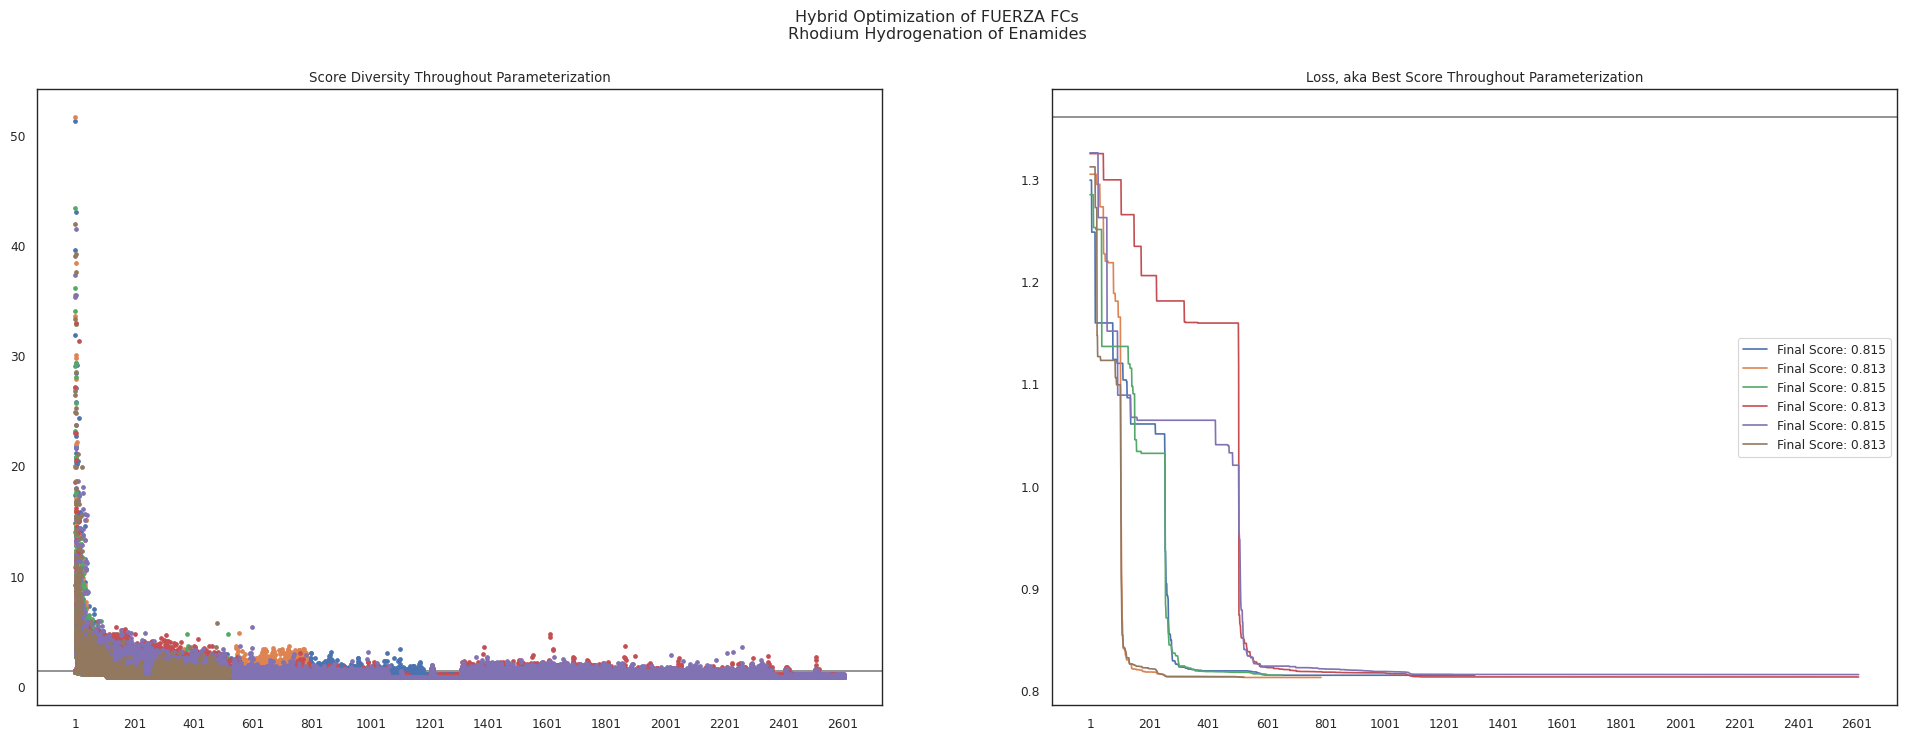

In [23]:
scores = ffplt.plot_history(base_directory, directory_list[:-1], 'Hybrid Optimization of FUERZA FCs\nRhodium Hydrogenation of Enamides', cycle_iter_length, fuerza_score)

In [24]:
%matplotlib inline
# Plot FCs

bonds = []
angles = []

bonds_rows = [str(bond_row+1) for bond_row in bond_rows]
angles_rows = [str(angle_row+1) for angle_row in angle_rows]

for directory, score in zip(directory_list[:-1], scores):
    bonds.append(pd.read_csv(os.path.join(base_directory, directory, 'mm3.hybrid.fld'), skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=score).assign(ff_row = bonds_rows))
    angles.append(pd.read_csv(os.path.join(base_directory, directory, 'mm3.hybrid.fld'), skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=score).assign(ff_row=angles_rows))
params = [pd.concat([bond, angle]) for bond, angle in zip(bonds, angles)]
cumulative_params.extend(params)

/tmp/ipykernel_290761/129704350.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  bonds.append(pd.read_csv(os.path.join(base_directory, directory, 'mm3.hybrid.fld'), skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=score).assign(ff_row = bonds_rows))
/tmp/ipykernel_290761/129704350.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  angles.append(pd.read_csv(os.path.join(base_directory, directory, 'mm3.hybrid.fld'), skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=score).assign(ff_row=angles_rows))
/tmp/ipykernel_290761/129704350.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  bonds.append(pd.read_csv(os.pat

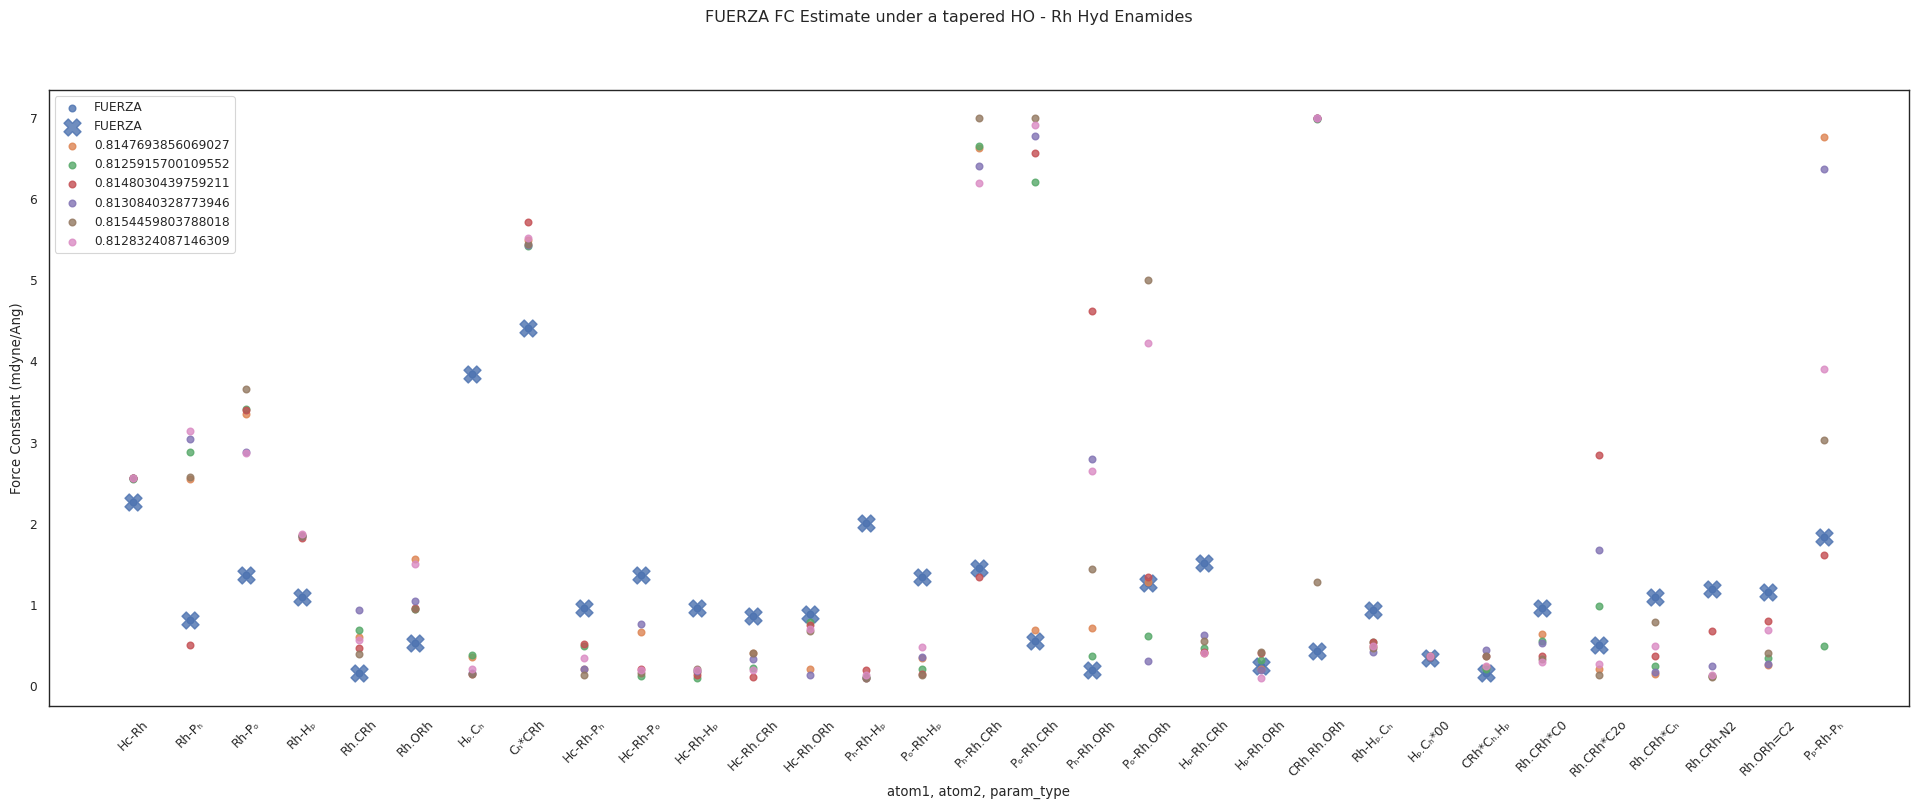

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(24, 8))
fig.suptitle('FUERZA FC Estimate under a tapered HO - Rh Hyd Enamides')

palette = itertools.cycle(seaborn.color_palette())

color = next(palette)
seaborn.regplot(data=melted_params_start, label='FUERZA', x = melted_params_start.ff_row, y="value", fit_reg=False, ax=ax, color=color)
seaborn.regplot(data=params_start, label='FUERZA', x =params_start.ff_row, y="Force Constant", marker='X', scatter_kws={'s':150}, fit_reg=False, ax=ax, color=color)

bond_labels = bonds[0][['atom1', 'atom2', 'param_type']].values
bond_labels = [str(bl) for bl in bond_labels]
angles_labels = angles[0][['atom1', 'atom2', 'atom3', 'param_type']].values
angles_labels = [str(al) for al in angles_labels]

for i in range(len(directory_list[:-1])):
    color = next(palette)
    seaborn.regplot(data=params[i], label=scores[i], x = params[i].ff_row, y="Force Constant", fit_reg=False, ax=ax, color=color)
    #seaborn.regplot(data=bonds[i], label=scores[i], x = rows[:8], y="Force Constant", fit_reg=False, ax=ax, color=color)
    #seaborn.regplot(data=angles[i], label=scores[i], x = rows[9:], y="Force Constant", fit_reg=False, ax=ax, color=color)

rows = [*bond_rows, *angle_rows]
rows = [str(row+1) for row in rows]

plt.xticks(rotation=45)
ax.legend()
ax.set_ylabel('Force Constant (mdyne/Ang)')
ax.set_xlabel('atom1, atom2, param_type')
plt.xticks(ticks=rows, labels=param_names)
plt.show()